### Install and Imports

In [1]:
# !pip install torch_geometric
# !pip install xgboost

import torch
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
   classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score,
    precision_score
)

**GRAPH CREATION FULL**

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# 1. Load and Sort Data
df = pd.read_csv('HI-Small_Trans.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(['Account', 'Timestamp']).reset_index(drop=True)

# 2. Extract NetworkX Graph Features (Node Level)
print("Computing NetworkX Centrality metrics...")
G = nx.from_pandas_edgelist(
    df, source='Account', target='Account.1', create_using=nx.DiGraph()
)

pagerank_scores = nx.pagerank(G, alpha=0.85)
hubs, authorities = nx.hits(G, max_iter=100, normalized=True)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)

# Topology Mappings
fan_in_map = df.groupby('Account.1')['Account'].nunique()
unique_recv_map = df.groupby('Account')['Account.1'].nunique()
user_avg_amt = df.groupby('Account')['Amount Received'].mean()

# 3. Create Node Features DataFrame
print("Building Node Features...")
unique_accounts = pd.concat([df['Account'], df['Account.1']]).unique()
accounts = pd.DataFrame({'Account': unique_accounts})

accounts['PageRank'] = accounts['Account'].map(pagerank_scores).fillna(0)
accounts['Hub_Score'] = accounts['Account'].map(hubs).fillna(0)
accounts['Authority_Score'] = accounts['Account'].map(authorities).fillna(0)
accounts['In_Degree'] = accounts['Account'].map(in_degree).fillna(0)
accounts['Out_Degree'] = accounts['Account'].map(out_degree).fillna(0)
accounts['Unique_Receivers'] = accounts['Account'].map(unique_recv_map).fillna(0)
accounts['Fan_In'] = accounts['Account'].map(fan_in_map).fillna(0)
accounts['Avg_Amount_Recv'] = accounts['Account'].map(user_avg_amt).fillna(0)

# Scale Node Features for GNN Stability
node_cols_to_scale = ['PageRank', 'Hub_Score', 'Authority_Score', 'In_Degree', 
                      'Out_Degree', 'Unique_Receivers', 'Fan_In', 'Avg_Amount_Recv']
accounts[node_cols_to_scale] = MinMaxScaler().fit_transform(accounts[node_cols_to_scale])

account_mapping = dict(zip(accounts['Account'], accounts.index))
node_features = torch.tensor(accounts[node_cols_to_scale].values, dtype=torch.float)

# 4. Create Edge/Velocity Features (Transaction Level)
print("Building Edge Velocity & Deviation Features...")
# Time since last transaction
df['Time_Since_Last_Txn'] = df.groupby('Account')['Timestamp'].diff().dt.total_seconds().fillna(0)

# Rolling counts and sums (Requires setting index to Timestamp temporarily)
temp_df = df.set_index('Timestamp')
r = temp_df.groupby('Account')['Amount Received']

# We map the rolling values back by aligning indexes
df['Count_1h'] = r.rolling('1h').count().values
df['Sum_1h']   = r.rolling('1h').sum().values
df['Count_24h'] = r.rolling('24h').count().values
df['Sum_24h']   = r.rolling('24h').sum().values

# Deviation Features
df['User_Avg_Amount'] = df.groupby('Account')['Amount Received'].transform('mean')
df['Amount_vs_Avg_Ratio'] = df['Amount Received'] / (df['User_Avg_Amount'] + 1)

# Normalize Time, Amounts, and Velocity metrics
edge_cols_to_scale = ['Amount Received', 'Amount Paid', 'Time_Since_Last_Txn', 
                      'Count_1h', 'Sum_1h', 'Count_24h', 'Sum_24h', 'Amount_vs_Avg_Ratio']
df[edge_cols_to_scale] = MinMaxScaler().fit_transform(df[edge_cols_to_scale])

print("Encoding Categorical Features...")
cat_cols = ['Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank', 'To Bank']
df_encoded = df.copy()

le = LabelEncoder()
for col in cat_cols:
    # Convert to string to handle any mixed types/NaNs, then label encode
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Scale the encoded integers to [0, 1] so they don't destabilize the GNN gradients
df_encoded[cat_cols] = MinMaxScaler().fit_transform(df_encoded[cat_cols])

# 5. Build PyG Data Object
print("Constructing PyTorch Geometric Data Object...")
src = df['Account'].map(account_mapping).values
dst = df['Account.1'].map(account_mapping).values

edge_indices = torch.stack([
    torch.tensor(src, dtype=torch.long), 
    torch.tensor(dst, dtype=torch.long)
], dim=0)

# Drop non-feature columns to isolate edge attributes
drop_cols = ['Timestamp', 'Account', 'Account.1', 'Is Laundering', 'User_Avg_Amount']
edge_features = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])

edge_attr = torch.tensor(edge_features.values, dtype=torch.float)
edge_labels = torch.tensor(df['Is Laundering'].values, dtype=torch.float)

# Final Graph Construction
graph = Data(
    x=node_features,
    edge_index=edge_indices,
    edge_attr=edge_attr,
    y=edge_labels
)

print(f"Graph Construction Complete:")
print(f" - Node Feature Dimension: {graph.x.shape[1]}")
print(f" - Edge Feature Dimension: {graph.edge_attr.shape[1]}")
print(graph)

Computing NetworkX Centrality metrics...
Building Node Features...
Building Edge Velocity & Deviation Features...
Encoding Categorical Features...
Constructing PyTorch Geometric Data Object...
Graph Construction Complete:
 - Node Feature Dimension: 8
 - Edge Feature Dimension: 13
Data(x=[515080, 8], edge_index=[2, 5078345], edge_attr=[5078345, 13], y=[5078345])


### Train/Valid/Test Split

In [10]:
all_idx   = torch.arange(graph.num_edges)
labels_np = edge_labels.numpy()

train_idx, test_idx = train_test_split(all_idx,     test_size=0.2,   stratify=labels_np,              random_state=42)
train_idx, val_idx  = train_test_split(train_idx,   test_size=0.125, stratify=labels_np[train_idx],   random_state=42)

graph.train_mask = train_idx
graph.val_mask   = val_idx
graph.test_mask  = test_idx

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Train: 3554841 | Val: 507835 | Test: 1015669


**UNDERSAMPLING**

In [20]:
import numpy as np

# Get labels for the training set only
train_labels = graph.y[graph.train_mask].numpy()

# Identify indices of minority (1) and majority (0) within the training set
illicit_train_mask = graph.train_mask[train_labels == 1]
benign_train_mask = graph.train_mask[train_labels == 0]

# Sample benign to be 10x the illicit count (or 1x for perfect balance)
undersample_ratio = 20 
np.random.seed(42)
sampled_benign_idx = np.random.choice(
    benign_train_mask.numpy(), 
    size=len(illicit_train_mask) * undersample_ratio, 
    replace=False
)

# Combine and shuffle
train_idx_balanced = torch.cat([illicit_train_mask, torch.tensor(sampled_benign_idx)])
train_idx_balanced = train_idx_balanced[torch.randperm(len(train_idx_balanced))]

print(f"Original Train Size: {len(graph.train_mask)}")
print(f"Balanced Train Size: {len(train_idx_balanced)}")

Original Train Size: 3554841
Balanced Train Size: 76104


**GNN Architecture - Multi PNA**

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import PNAConv, BatchNorm
from torch_geometric.utils import degree

# 1. Get the target nodes (destination nodes) for all edges in your graph
# edge_index[1] represents the target/destination nodes
row, col = graph.edge_index

# 2. Compute the degree for each node
# num_nodes ensures the tensor is the correct size even for isolated nodes
deg = degree(col, num_nodes=graph.num_nodes, dtype=torch.long)

# 3. Compute the bincount to get the frequency of each degree value
# This is the "histogram" PNA needs
deg_distribution = torch.bincount(deg)

print(f"Max degree in graph: {deg.max().item()}")
print(f"Histogram size: {deg_distribution.shape[0]}")

class AMLMultiPNA(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim=64, deg=None):
        super().__init__()
        aggregators = ['mean', 'min', 'max', 'std']
        scalers = ['identity', 'amplification', 'attenuation']
        
        # PNA Convolutional Layers
        self.conv1 = PNAConv(node_in_dim, hidden_dim, aggregators=aggregators, 
                             scalers=scalers, deg=deg, edge_dim=edge_in_dim, towers=4)
        self.bn1 = BatchNorm(hidden_dim)
        
        self.conv2 = PNAConv(hidden_dim, hidden_dim, aggregators=aggregators, 
                             scalers=scalers, deg=deg, edge_dim=edge_in_dim, towers=4)
        self.bn2 = BatchNorm(hidden_dim)

        # Classifier for Edge/Link prediction
        classifier_in_dim = (hidden_dim * 2) + edge_in_dim
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),# <-- Prevents dead neurons from weighted loss            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),            
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def get_node_embeddings(self, x, edge_index, edge_attr):
        if edge_attr.dim() == 1: edge_attr = edge_attr.view(-1, 1)
        x = self.bn1(F.relu(self.conv1(x, edge_index, edge_attr)))
        x = self.bn2(F.relu(self.conv2(x, edge_index, edge_attr)))
        return x

    def forward(self, x, edge_index, edge_attr, edge_label_index):
        node_x = self.get_node_embeddings(x, edge_index, edge_attr)
        src, dst = edge_label_index
        target_edge_attr = edge_attr[:edge_label_index.size(1)]
        if target_edge_attr.dim() == 1: target_edge_attr = target_edge_attr.view(-1, 1)

        edge_repr = torch.cat([node_x[src], node_x[dst], target_edge_attr], dim=-1)
        return self.classifier(edge_repr).squeeze(-1)

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        """
        alpha: Weighting factor for the rare class (illicit transactions).
               Higher alpha biases the model toward finding fraud.
        gamma: The focusing parameter. Higher gamma pushes the model to 
               focus strictly on hard, misclassified examples.
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Compute standard BCE loss (without reduction so we can modify it)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Get the probabilities of the positive class
        probs = torch.sigmoid(logits)
        
        # Calculate p_t (probability of the TRUE class)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate the modulating factor: (1 - p_t)^gamma
        modulating_factor = (1 - p_t) ** self.gamma
        
        # Apply the alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Final Focal Loss calculation
        focal_loss = alpha_t * modulating_factor * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# --- INITIALIZATION ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure deg_distribution was calculated from your graph earlier!
model = AMLMultiPNA(
    node_in_dim=graph.x.shape[1], 
    edge_in_dim=graph.edge_attr.shape[1], 
    deg=deg_distribution
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay = 1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
pos_weight_val = torch.tensor([float(undersample_ratio)]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

print(f"Model initialized on {device}")

Max degree in graph: 1084
Histogram size: 1085
Model initialized on cuda


D:\Anaconda\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


**To Handle Out of Memory Error due to lack of compute**

In [22]:
from torch_geometric.loader import LinkNeighborLoader

train_edge_label_index = graph.edge_index[:, train_idx_balanced]

# 2. Get the corresponding labels
train_edge_labels = graph.y[train_idx_balanced]

train_loader = LinkNeighborLoader(
    data=graph,
    num_neighbors=[25, 15],     # 1st and 2nd hop sampling
    edge_label_index=train_edge_label_index,
    edge_label=graph.y[train_idx_balanced],
    batch_size=4096,
    shuffle=True,
    # This is important: it ensures the edge features for the 
    # target edges are included in the batch
    neg_sampling_ratio=0.0
)

**TRAINING, VALIDATION AND TESTING**

Starting training for 80 epochs on cuda...

Epoch 001 | Average Training Loss: 0.2283 | Time: 15.64s
--- Validation Results ---
Average Val Loss:  0.1463
Optimal Threshold: 0.9946
F1: 0.4268 | Precision: 0.4741 | Recall: 0.3880 | AUC: 0.9777 | PR-AUC: 0.3701

>>> Best Model Checkpoint Saved!

Epoch 002 | Average Training Loss: 0.2210 | Time: 15.70s
--- Validation Results ---
Average Val Loss:  0.1424
Optimal Threshold: 0.9961
F1: 0.4505 | Precision: 0.5405 | Recall: 0.3861 | AUC: 0.9805 | PR-AUC: 0.3878

>>> Best Model Checkpoint Saved!

Epoch 003 | Average Training Loss: 0.2221 | Time: 15.99s
--- Validation Results ---
Average Val Loss:  0.1146
Optimal Threshold: 0.9946
F1: 0.4675 | Precision: 0.6218 | Recall: 0.3745 | AUC: 0.9795 | PR-AUC: 0.4126

>>> Best Model Checkpoint Saved!

Epoch 004 | Average Training Loss: 0.2199 | Time: 9.08s
--- Validation Results ---
Average Val Loss:  0.1520
Optimal Threshold: 0.9970
F1: 0.4857 | Precision: 0.5175 | Recall: 0.4575 | AUC: 0.9794 | PR-AUC:

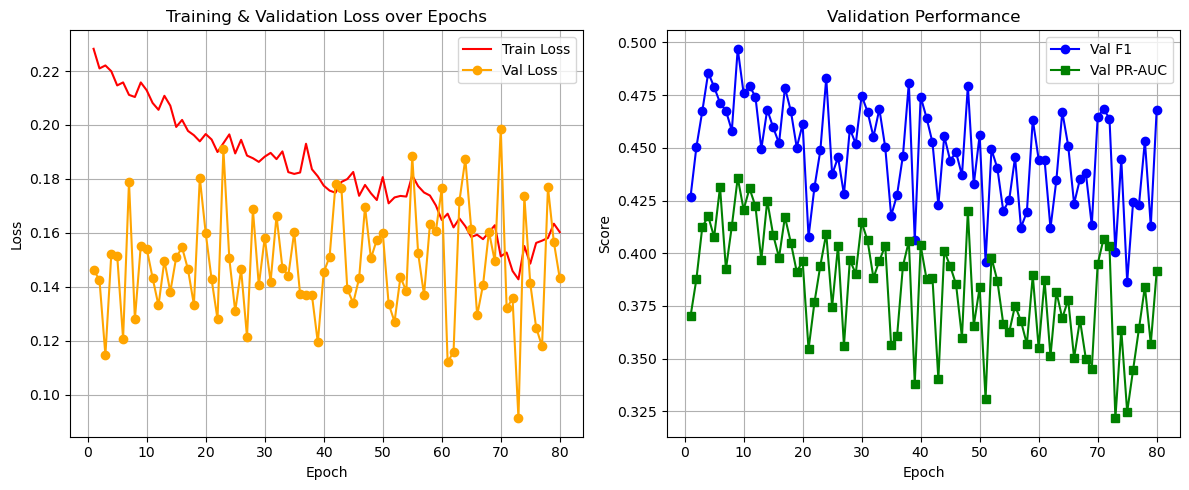

In [17]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             roc_auc_score, precision_recall_curve, 
                             average_precision_score, confusion_matrix, 
                             classification_report, PrecisionRecallDisplay)
from torch_geometric.loader import LinkNeighborLoader

# --- 1. Loaders (Assuming train_loader and val_loader are defined here) ---
val_loader = LinkNeighborLoader(
    data=graph,
    num_neighbors=[25, 15],
    edge_label_index=graph.edge_index[:, graph.val_mask],
    edge_label=graph.y[graph.val_mask],
    batch_size=4096, 
    shuffle=False,
)

# --- 2. Train and Evaluate Functions ---
def train_one_epoch():
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        loss = loss_fn(logits, batch.edge_label.float())
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate_dynamic(loader, loss_fn, mask_name="Validation"):
    model.eval()
    all_logits = []
    all_labels = []
    total_val_loss = 0.0 # <-- Add this tracker
    
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        
        # Ensure logits are properly shaped before loss calculation
        if logits.dim() > 1:
            logits = logits.squeeze(-1)
            
        # --- CALCULATE BATCH LOSS HERE ---
        loss = loss_fn(logits, batch.edge_label.float())
        total_val_loss += loss.item() 
        # ---------------------------------
        
        all_logits.append(logits.cpu())
        all_labels.append(batch.edge_label.cpu())
        
    # Calculate average loss for the entire validation set
    avg_val_loss = total_val_loss / len(loader)
        
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_labels).numpy()
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    
    if best_idx == len(thresholds):
        best_threshold = 1.0
    else:
        best_threshold = thresholds[best_idx]
        
    best_f1 = f1_scores[best_idx]
    best_precision = precisions[best_idx]
    best_recall = recalls[best_idx]
    auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    
    print(f"--- {mask_name} Results ---")
    print(f"Average Val Loss:  {avg_val_loss:.4f}") # <-- Print it
    print(f"Optimal Threshold: {best_threshold:.4f}")
    print(f"F1: {best_f1:.4f} | Precision: {best_precision:.4f} | Recall: {best_recall:.4f} | AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}\n")
    
    # Return the val_loss so you can track it in your history lists
    return {"f1": best_f1, "threshold": best_threshold, "pr_auc": pr_auc, "val_loss": avg_val_loss}

# --- 3. The Main Execution Loop (With Timing and Tracking) ---
EPOCHS = 80
best_val_f1 = 0.0

# Tracking lists for plotting
history_epochs = []
history_train_loss = []
history_val_loss = []
history_val_epochs = [] # Val is only checked every 5 epochs
history_val_f1 = []
history_val_prauc = []
epoch_times = []

print(f"Starting training for {EPOCHS} epochs on {device}...\n")
total_start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    
    avg_train_loss = train_one_epoch()
    
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    epoch_times.append(epoch_duration)
    
    # Track training loss for every epoch
    history_epochs.append(epoch)
    history_train_loss.append(avg_train_loss)
    
    if epoch % 1 == 0:
        print(f"Epoch {epoch:03d} | Average Training Loss: {avg_train_loss:.4f} | Time: {epoch_duration:.2f}s")
        
        val_metrics = evaluate_dynamic(val_loader, loss_fn, mask_name="Validation")        

        history_val_epochs.append(epoch)
        history_val_loss.append(val_metrics['val_loss'])
        history_val_f1.append(val_metrics['f1'])
        history_val_prauc.append(val_metrics['pr_auc'])
        
        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), 'best_aml_pna_model.pt')
            print(">>> Best Model Checkpoint Saved!\n")

total_end_time = time.time()
total_duration = total_end_time - total_start_time
avg_epoch_time = sum(epoch_times) / len(epoch_times)

print("="*40)
print(f"TRAINING COMPLETE")
print(f"Total Wall-Clock Time: {total_duration / 60:.2f} minutes")
print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")
print("="*40)

# --- 4. Plot Training vs Validation Metrics ---
plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)

# Plot the training loss (every epoch)
plt.plot(history_epochs, history_train_loss, label='Train Loss', color='red')

# Plot the validation loss (every 5 epochs)
plt.plot(history_val_epochs, history_val_loss, label='Val Loss', color='orange', marker='o')

plt.title('Training & Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Validation Metrics
plt.subplot(1, 2, 2)
plt.plot(history_val_epochs, history_val_f1, label='Val F1', marker='o', color='blue')
plt.plot(history_val_epochs, history_val_prauc, label='Val PR-AUC', marker='s', color='green')
plt.title('Validation Performance')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 5. Final Test Evaluation (With Confusion Matrix and PR Curve) ---
@torch.no_grad()
def final_test_evaluation(loader, optimal_threshold=0.5):
    model.load_state_dict(torch.load('best_aml_pna_model.pt'))
    model.eval()
    
    all_logits = []
    all_labels = []
    
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        
        if logits.dim() > 1:
            logits = logits.squeeze(-1)
            
        all_logits.append(logits.cpu())
        all_labels.append(batch.edge_label.cpu())
        
        del batch
        del logits
        torch.cuda.empty_cache() 
        
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_pred = (probs >= optimal_threshold).astype(int)
    
    # Base Metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    
    print("\n" + "="*40)
    print("FINAL TEST SET RESULTS")
    print("="*40)
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print("="*40)

    # 1. Classification Report (Breakdown per class)
    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=["Normal (0)", "Fraud (1)"], digits=4))

    # 2. Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred Normal', 'Pred Fraud'],
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f'Confusion Matrix (Threshold = {optimal_threshold})')
    plt.show()

    # 3. PR-AUC Curve Plot
    plt.figure(figsize=(7, 6))
    PrecisionRecallDisplay.from_predictions(y_true, probs, name="MultiPNA", color="darkorange")
    plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

test_loader = LinkNeighborLoader(
    data=graph,
    num_neighbors=[25, 15],
    edge_label_index=graph.edge_index[:, graph.test_mask],
    edge_label=graph.y[graph.test_mask],
    batch_size=4096, 
    shuffle=False,
)


FINAL TEST SET RESULTS
F1 Score:  0.4830
Precision: 0.4995
Recall:    0.4676
ROC-AUC:   0.9786
PR-AUC:    0.4071

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  Normal (0)     0.9995    0.9995    0.9995   1014634
   Fraud (1)     0.4995    0.4676    0.4830      1035

    accuracy                         0.9990   1015669
   macro avg     0.7495    0.7336    0.7413   1015669
weighted avg     0.9989    0.9990    0.9990   1015669



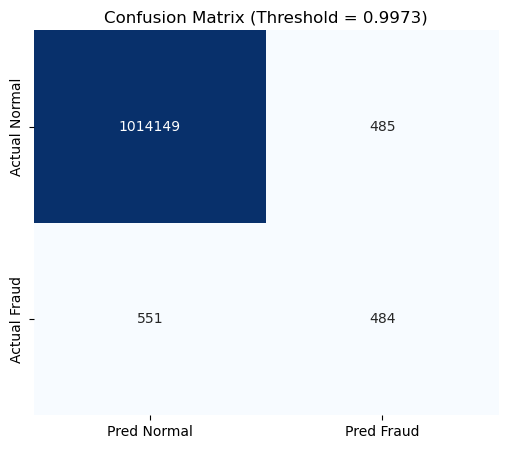

<Figure size 700x600 with 0 Axes>

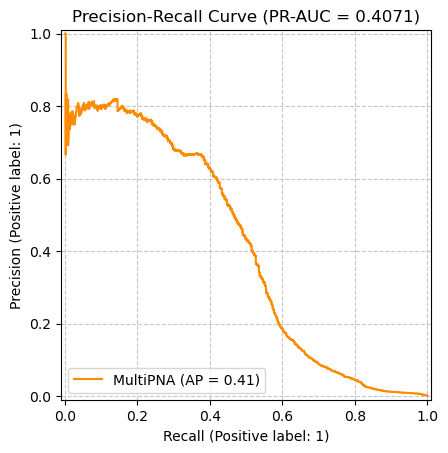

In [18]:
final_test_evaluation(test_loader, optimal_threshold=0.9973)

**FINAL TEST RESULTS - EARLIER RUN**


FINAL TEST SET RESULTS
F1 Score:  0.5566 (at thresh 0.9984)
Precision: 0.7311
Recall:    0.4493
AUC:       0.9776
PR-AUC     0.4810


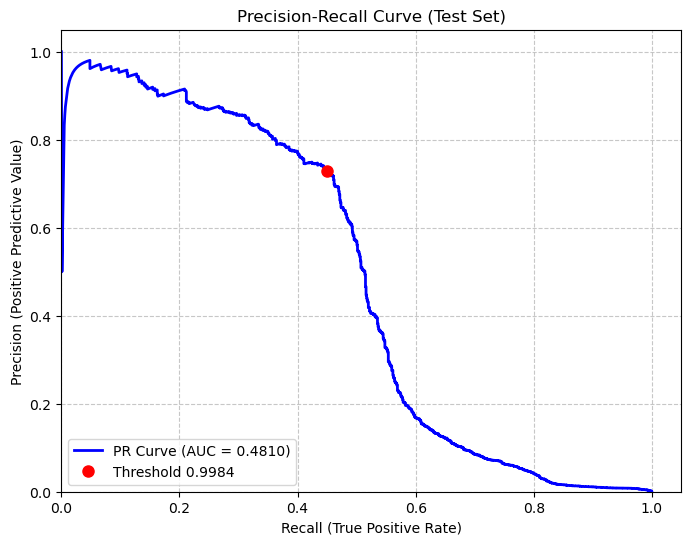

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, precision_recall_curve
from torch_geometric.loader import LinkNeighborLoader
import torch

# 1. Initialize the Test Loader 
# (Note: make sure 'graph' here is your properly temporally-split graph!)
test_loader = LinkNeighborLoader(
    data=graph,
    num_neighbors=[25, 15],
    edge_label_index=graph.edge_index[:, graph.test_mask],
    edge_label=graph.y[graph.test_mask],
    batch_size=4096, 
    shuffle=False,
)

model = AMLMultiPNA(
    node_in_dim=graph.x.shape[1], 
    edge_in_dim=13, 
    deg=deg_distribution
).to(device)

# 2. Define the Test Evaluation Function
@torch.no_grad()
def final_test_evaluation(loader, optimal_threshold=0.5):
    # Load best model
    model.load_state_dict(torch.load('best_aml_pna_model.pt'))
    model.eval()
    
    all_logits = []
    all_labels = []
    
    for batch in loader:
        batch = batch.to(device)
        
        # Forward pass matching YOUR MultiPNA architecture
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index)
        
        # Ensure logits are 1D (flattened)
        if logits.dim() > 1:
            logits = logits.squeeze(-1)
        
        # Move to CPU immediately
        all_logits.append(logits.cpu())
        all_labels.append(batch.edge_label.cpu())
        
        # Memory management
        del batch
        del logits
        torch.cuda.empty_cache() 
        
    probs = torch.sigmoid(torch.cat(all_logits)).numpy()
    y_true = torch.cat(all_labels).numpy()
    
    y_pred = (probs >= optimal_threshold).astype(int)
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, probs)
    pr_auc = average_precision_score(y_true, probs)
    
    print("\n" + "="*40)
    print("FINAL TEST SET RESULTS")
    print("="*40)
    print(f"F1 Score:  {f1:.4f} (at thresh {optimal_threshold})")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"PR-AUC     {pr_auc:.4f}")
    print("="*40)

    # ---------------------------------------------------------
    # PLOT THE PR CURVE
    # ---------------------------------------------------------
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='b', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
    
    # Mark the spot of your chosen threshold on the curve
    # Find the index of the threshold closest to your optimal_threshold
    closest_thresh_idx = abs(thresholds - optimal_threshold).argmin()
    # plt.plot(recalls[closest_thresh_idx], precisions[closest_thresh_idx], 'ro', markersize=8, 
             # label=f'Threshold {optimal_threshold}')

    plt.xlabel('Recall (True Positive Rate)')
    plt.ylabel('Precision (Positive Predictive Value)')
    plt.title('Precision-Recall Curve (Test Set)')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.show()

# Run the evaluation
final_test_evaluation(test_loader, optimal_threshold=0.9984)